Analytic cohort size: 2039
Survivors (broad): 349
Calculating ground truth τ using continuous time (L2)...
Ground truth threshold (continuous data): τ = 19.20 minutes

Processing 1-minute bins...
  -> Estimated τ = 6.80 min

Processing 2-minute bins...
  -> Estimated τ = 13.00 min

Processing 3-minute bins...
  -> Estimated τ = 7.40 min

Processing 4-minute bins...
  -> Estimated τ = 14.00 min

Processing 5-minute bins...
  -> Estimated τ = 7.40 min


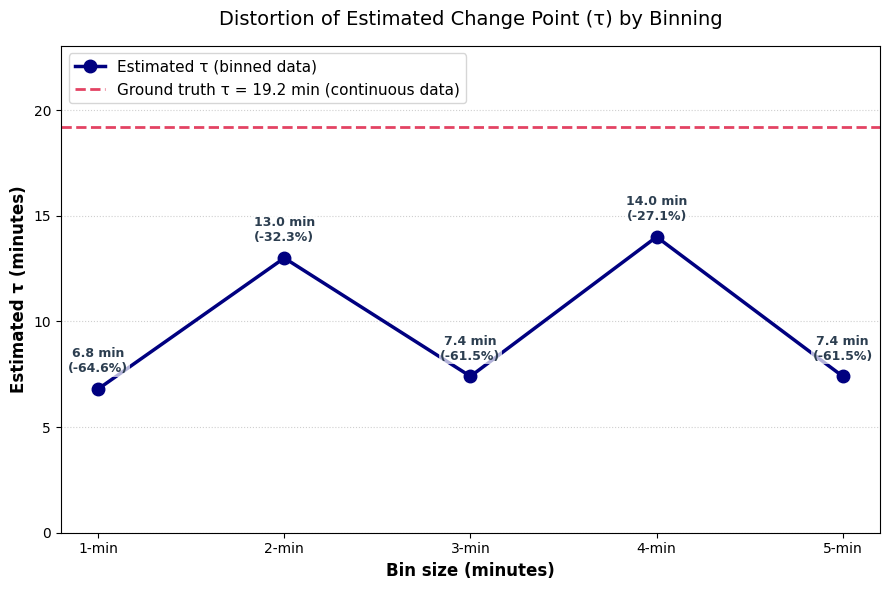

In [3]:
# ==========================================
# RQ2: Binning Distortion Analysis
# Using L2‑regularized Logistic Regression
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings

# ------------------------------
# 1. Load and prepare data
# ------------------------------
CURRENT_DIRECTORY = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents] if (p / "datasets").exists())
CLEANED_DATASET_PATH = PROJECT_ROOT / "datasets" / "PAROS_Dataset_Cleaned.csv"
df = pd.read_csv(CLEANED_DATASET_PATH)

# Define broad survival (discharged alive or still in hospital at 30 days)
outcome_cols = ['Outcome of patient', 'Patient status', 'Final status at scene']
available_cols = [col for col in outcome_cols if col in df.columns]
df['Outcome_String'] = df[available_cols].astype(str).agg(' '.join, axis=1)
survival_regex = r'Discharged Alive|Remains in hospital at 30th day|Survived to discharge'
df['Survival_Binary'] = df['Outcome_String'].str.contains(survival_regex, case=False, regex=True).astype(int)

# Keep rows with valid time to defib
rq2_df = df[df['Time_to_Defib'].notna()].copy()
rq2_df['Outcome'] = rq2_df['Survival_Binary']
print(f"Analytic cohort size: {len(rq2_df)}")
print(f"Survivors (broad): {rq2_df['Outcome'].sum()}")

# ------------------------------
# 2. Function: find optimal τ using L2 logistic regression
# ------------------------------
def find_optimal_tau_l2(df, time_col, outcome_col, tau_candidates, C=0.1):
    """
    Grid search for change point τ using L2-regularized logistic regression.
    Returns the τ that maximizes log‑likelihood.
    """
    df_clean = df.dropna(subset=[time_col, outcome_col]).copy()
    y = df_clean[outcome_col].values
    best_tau = None
    max_ll = -np.inf

    for tau in tau_candidates:
        X_early = np.clip(df_clean[time_col], a_min=None, a_max=tau)
        X_late  = np.clip(df_clean[time_col] - tau, a_min=0, a_max=None)
        
        # Skip if either feature has zero variance
        if np.std(X_early) < 1e-8 or np.std(X_late) < 1e-8:
            continue
        
        X = np.column_stack([X_early, X_late])
        # Standardize features for numerical stability
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        try:
            model = LogisticRegression(penalty='l2', C=C, solver='lbfgs', max_iter=1000)
            model.fit(X_scaled, y)
            pred_prob = model.predict_proba(X_scaled)[:, 1]
            pred_prob = np.clip(pred_prob, 1e-15, 1-1e-15)
            ll = np.sum(y * np.log(pred_prob) + (1-y) * np.log(1-pred_prob))
            
            if ll > max_ll:
                max_ll = ll
                best_tau = tau
        except Exception as e:
            # If convergence fails, skip this tau
            continue
    return best_tau

# ------------------------------
# 3. Ground truth τ on continuous time
# ------------------------------
tau_grid = np.arange(1.0, 20.1, 0.2)
print("Calculating ground truth τ using continuous time (L2)...")
ground_truth_tau = find_optimal_tau_l2(rq2_df, 'Time_to_Defib', 'Outcome', tau_grid, C=0.1)

if ground_truth_tau is None:
    raise RuntimeError("Ground truth τ could not be estimated – check data or grid range.")
print(f"Ground truth threshold (continuous data): τ = {ground_truth_tau:.2f} minutes")

# ------------------------------
# 4. Binning simulation (1‑ to 5‑min bins)
# ------------------------------
bin_sizes = [1, 2, 3, 4, 5]
discovered_taus = []

for bin_sz in bin_sizes:
    print(f"\nProcessing {bin_sz}-minute bins...")
    df_temp = rq2_df.copy()
    bins = np.arange(0, df_temp['Time_to_Defib'].max() + bin_sz + 1, bin_sz)
    df_temp['Time_Bin'] = pd.cut(df_temp['Time_to_Defib'], bins=bins, right=False)
    df_temp['Binned_Time'] = df_temp['Time_Bin'].apply(lambda x: x.mid).astype(float)
    
    if df_temp['Binned_Time'].nunique() < 3:
        print(f"  -> Warning: only {df_temp['Binned_Time'].nunique()} unique binned times. Skipping.")
        discovered_taus.append(np.nan)
        continue
    
    binned_tau = find_optimal_tau_l2(df_temp, 'Binned_Time', 'Outcome', tau_grid, C=0.1)
    if binned_tau is None:
        print(f"  -> No stable τ found for {bin_sz}-min bins.")
        discovered_taus.append(np.nan)
    else:
        print(f"  -> Estimated τ = {binned_tau:.2f} min")
        discovered_taus.append(binned_tau)

# ------------------------------
# 5. Visualisation
# ------------------------------
plt.figure(figsize=(9, 6))
plt.plot(bin_sizes, discovered_taus, marker='o', markersize=9, linestyle='-', linewidth=2.5,
         color='navy', label='Estimated τ (binned data)')
plt.axhline(y=ground_truth_tau, color='crimson', linestyle='--', linewidth=2, alpha=0.8,
            label=f'Ground truth τ = {ground_truth_tau:.1f} min (continuous data)')

for i, (bs, tau_est) in enumerate(zip(bin_sizes, discovered_taus)):
    if pd.notna(tau_est):
        distortion = ((tau_est - ground_truth_tau) / ground_truth_tau) * 100
        sign = "+" if distortion > 0 else ""
        label = f"{tau_est:.1f} min\n({sign}{distortion:.1f}%)"
        plt.annotate(label, (bs, tau_est), textcoords="offset points", xytext=(0, 12),
                     ha='center', fontsize=9, fontweight='bold', color='#2c3e50',
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

plt.ylim(bottom=0, top=max(discovered_taus + [ground_truth_tau]) * 1.2)
plt.title('Distortion of Estimated Change Point (τ) by Binning', fontsize=14, pad=15)
plt.ylabel('Estimated τ (minutes)', fontsize=12, fontweight='bold')
plt.xlabel('Bin size (minutes)', fontsize=12, fontweight='bold')
plt.xticks(bin_sizes, [f"{b}-min" for b in bin_sizes])
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('RQ2_Binning_Deviation_L2.png', dpi=300, bbox_inches='tight')
plt.show()